Question 3:

Orders are 1, 1, 2 respectively

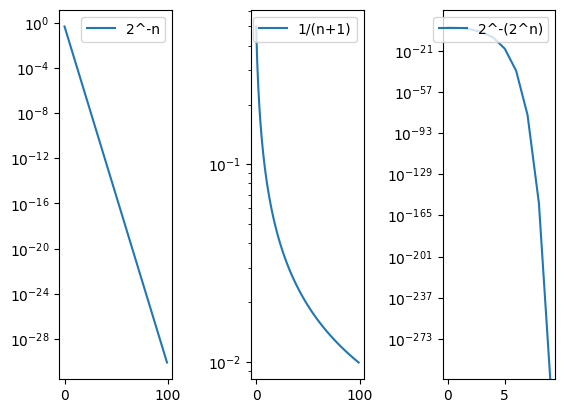

In [ ]:
import matplotlib.pyplot as plt 

sequence1 = [(2**-n) for n in range(1,101)]
sequence2 = [(1/(n+1)) for n in range(1,101)]
sequence3 = [(2**-(2**n)) for n in range(1,11)]


figure, axis = plt.subplots(1, 3)
plt.subplots_adjust(wspace=0.7) 


axis[0].plot(sequence1, label='2^-n')
axis[1].plot(sequence2, label='1/(n+1)')
axis[2].plot(sequence3, label='2^-(2^n)')
for n in range(3):
  axis[n].set_yscale('log')
  axis[n].legend(loc='upper right')
  
plt.show()



Question 4:
Yes
No
Yes
Reasoning on worksheet

In [52]:
import mpmath

mpmath.mpf.dps = 100
pi = mpmath.pi

def leibnitz(n):
  pi_approx = mpmath.mpf(0)
  for k in range(0,n+1):
    pi_approx += ((-1)**k)/(2*k+1)
  approximations = [pi_approx , pi_approx + ((-1)**(n+1))/(2*(n+1)+1), pi_approx + ((-1)**(n+1))/(2*(n+1)+1) + ((-1)**(n+2))/(2*(n+2)+1)]
  return approximations

e_10000, e_10001, e_10002 = [abs(4*e - pi) for e in leibnitz(10000)]

q = mpmath.log(e_10002/e_10001)/mpmath.log(e_10001/e_10000)
m = e_10001/(e_10000**q)
print(f"q: {q}, m: {m}")

q: 0.999903396579754, m: 0.999010744761821


Conjecture: Its convergence order is 1

Part C)

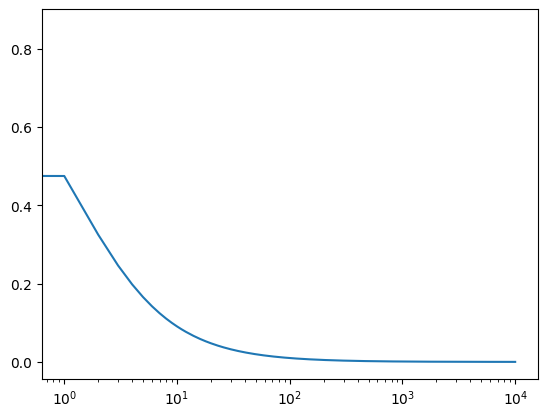

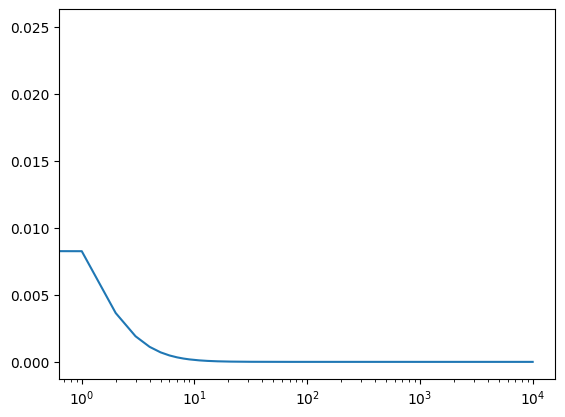

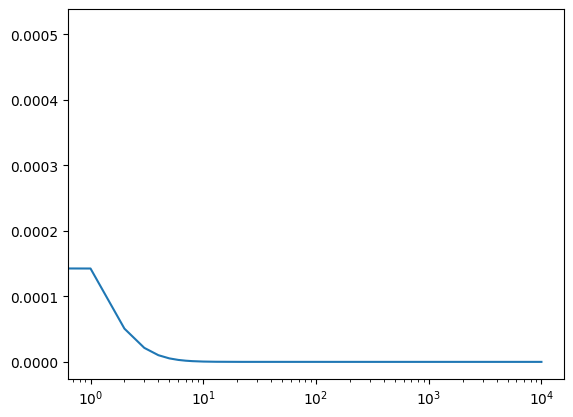

Last 3 errors of sequence 1: [mpf('2.5890400934258651e-13'), mpf('2.4158453015843406e-13'), mpf('2.5890400934258651e-13')]
Last 3 errors of sequence 2: [mpf('8.8817841970012523e-15'), mpf('8.8817841970012523e-15'), mpf('8.8817841970012523e-15')]
q_1: 0.99342653567126, q_2: 0.985230122827355


In [ ]:
import matplotlib.pyplot as plt 
mpmath.mpf.dps = 100000

errors = []
errors_1 = []
errors_2 = []
a = []
a_1 = [] # 1st Aitken extrapolation
a_2 = [] # 2nd Aitken extrapolation

pi_approx = mpmath.mpf(0)
for n in range(1, 10001):
  pi_approx += ((-1)**(n-1))/(2*(n-1)+1)
  errors.append(abs(4*pi_approx - pi))
  a.append(4*pi_approx)

for n in range(0, len(a)-2):
  a_1.append(a[n] - ((a[n+1] - a[n])**2)/(a[n+2] - 2*a[n+1] + a[n]))
  errors_1.append(abs(a_1[n] - pi))

for n in range(0, len(a_1)-2):
  a_2.append(a_1[n] - ((a_1[n+1] - a_1[n])**2)/(a_1[n+2] - 2*a_1[n+1] + a_1[n]))
  errors_2.append(abs(a_2[n] - pi))


plt.plot(errors)
plt.xscale('log')
plt.show()

plt.plot(errors_1)
plt.xscale('log')
plt.show()

plt.plot(errors_2)
plt.xscale('log')
plt.show()

# Estimating e from 10000-> 10002 leads to errors due to computer precision, so using smaller.
q_1 = mpmath.log(errors_1[1002]/errors_1[1001])/mpmath.log(errors_1[1001]/errors_1[1000])
q_2 = mpmath.log(errors_2[102]/errors_2[101])/mpmath.log(errors_2[101]/errors_2[100])
print(f"q_1: {q_1}, q_2: {q_2}")


Conjecture: Aitken Acceleration preserves rate of convergence.